<a href="https://colab.research.google.com/github/renzoardiles-pixel/Colab-UNI/blob/main/SQL/M%C3%B3dulo_6_Vistas_y_Consideraciones_de_Seguridad_B%C3%A1sica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

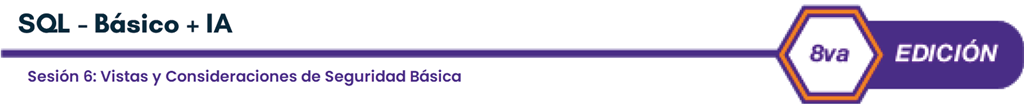

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Vistas</font>**

</td>
</tr>
</table>

Las vistas en SQL Server son objetos de base de datos que permiten almacenar consultas SQL completas.

Funcionalmente, son como tablas virtuales que ofrecen una manera de simplificar el acceso a datos complejos, encapsular lógica de consulta y proporcionar un nivel adicional de seguridad.



```
USE pvl
GO
IF EXISTS
(
	SELECT name
	FROM sys.views
	WHERE name = 'v_top_5_apellidos'
)
DROP VIEW v_top_5_apellidos
GO
CREATE VIEW v_top_5_apellidos AS
-- Mostrar los 5 apellidos que se encuentrar en mayor cantidad en la tabla Beneficiario
SELECT TOP 5
	Apellido, COUNT(*) AS Cantidad
FROM
(
SELECT pat_ben_vc AS Apellido
FROM Beneficiario
UNION ALL -- No elimina repetidos
SELECT mat_ben_vc
FROM Beneficiario
) AS Apellidos
GROUP BY Apellido
ORDER BY Cantidad DESC
GO
SELECT * FROM v_top_5_apellidos
GO
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Vista Encriptada</font>**

</td>
</tr>
</table>



```
USE pvl
GO
IF EXISTS
(
	SELECT name
	FROM sys.views
	WHERE name = 'v_top_5_apellidos'
)
DROP VIEW v_top_5_apellidos
GO
CREATE VIEW v_top_5_apellidos
WITH ENCRYPTION
AS
SELECT TOP 5
	Apellido, COUNT(*) AS Cantidad
FROM
(
SELECT pat_ben_vc AS Apellido
FROM Beneficiario
UNION ALL -- No elimina repetidos
SELECT mat_ben_vc
FROM Beneficiario
) AS Apellidos
GROUP BY Apellido
ORDER BY Cantidad DESC
GO
SELECT * FROM v_top_5_apellidos
GO
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Para Visualizar el Contenido de la Vista</font>**

</td>
</tr>
</table>



```
USE pvl
GO
sp_helptext 'dbo.v_top_5_apellidos'
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Para Visualizar las tablas y campos de una vista encriptas</font>**

</td>
</tr>
</table>



```
USE pvl
GO
sp_depends 'dbo.v_top_5_apellidos'
```





```
USE pvl
GO
SET SHOWPLAN_ALL ON
GO
SELECT *
FROM dbo.v_top_5_apellidos
GO
SET SHOWPLAN_ALL OFF
```



<table width='99%'>
<tr>
<td bgcolor='#5b2c6f'>

## **<font color="#FFFFFF">Vista con Esquema</font>**

</td>
</tr>
</table>



```
USE deltron
GO
CREATE OR ALTER VIEW Ventas.vw_listado AS
SELECT
	cod_prd_in,
	cod_prd_vc,
	nom_prd_vc,
	pre_ven_prd_mo,
	l.cod_lin_in,
	l.nom_lin_vc
	cod_mar_in
FROM Almacen.producto p
INNER JOIN Almacen.linea l ON p.cod_lin_in = l.cod_lin_in
GO
SELECT * FROM Ventas.vw_listado
GO
```

